# Hypothesis Testing the Data we have

I am testing weather a markets price is related to its outcome. i.e if a market is priced at 70% yes does that market result in yes 70% of the time.

A few things to note on the structure of the data:
- Not all the data has 6-month returns on the time to expiry
    - Most of the markets are shorter than 6-months
- There is a lot of correlation between data
    - A lot of the markets in the dataset are yes/no on different prices for the same thing, this will need to be accounted for.

The first thing that we will need to fix is the multiple lengths of the different markets.

In [1]:
#imports
import pandas as pd
import csv
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

notebook_dir = os.path.abspath('')
sys.path.insert(0, os.path.join(notebook_dir, '..', 'src'))
from Reports_HT import Report

market_data = "../Data/poly_data_test.csv"

In [2]:
# See what data we have and how many different markets we have.
market_data_df = pd.read_csv(market_data)
market_data_df

,question,yes_6mo,no_6mo,yes_3mo,no_3mo,yes_1mo,no_1mo,yes_1wk,no_1wk,yes_1day,no_1day,yes_resolution,no_resolution,category,outcome,condition_id,resolution_date,missing_horizons
0,Katana FDV above $1B one day after launch?,NaN,NaN,NaN,NaN,NaN,NaN,0.0015,0.9985,0.0005,0.9995,0.0005,0.9995,NaN,0,0x8ccc3f4951ff02c1d34b87988752b4444ad172287327...,2026-03-19T23:20:15+00:00,"6mo,3mo,1mo"
1,Espresso FDV above $700M one day after launch?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0025,0.9975,0.0005,0.9995,NaN,0,0x3cc74c68476657c35e0c7c4bb4de55dbf7a94086b088...,2026-02-14T00:09:43+00:00,"6mo,3mo,1mo,1wk"
2,Espresso FDV above $200M one day after launch?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8500,0.1500,0.9995,0.0005,NaN,1,0x374e86da7257106731513b2b381ac247ceed0b0f76c0...,2026-02-14T00:15:41+00:00,"6mo,3mo,1mo,1wk"
3,Espresso FDV above $100M one day after launch?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9975,0.0025,0.9995,0.0005,NaN,1,0xd867a7cf502287eb1a05834adeeb1c805590fe03aeaa...,2026-02-14T00:11:35+00:00,"6mo,3mo,1mo,1wk"
4,Espresso FDV above $1B one day after launch?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0015,0.9985,0.0005,0.9995,NaN,0,0x7680e424433b93c68665d4a28cdf1bf9fa7295238e3a...,2026-02-14T00:08:43+00:00,"6mo,3mo,1mo,1wk"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,Will Fabian Hurzeler be the next permanent man...,NaN,NaN,NaN,NaN,NaN,NaN,0.1005,0.8995,0.0020,0.9980,0.0005,0.9995,NaN,0,0x0389585c1faad056d90b20e793823cbe0ad0d3804d18...,2026-05-17T11:08:50+00:00,"6mo,3mo,1mo"
980,Will Thierry Henry be the next permanent manag...,NaN,NaN,NaN,NaN,NaN,NaN,0.4415,0.5585,0.0015,0.9985,0.0005,0.9995,NaN,0,0x4b43ab7a40a0f9b9e68f570587a608a0a165406c4ab4...,2026-05-17T10:50:57+00:00,"6mo,3mo,1mo"
981,Will Steve Kerr join the Los Angeles Clippers ...,NaN,NaN,NaN,NaN,NaN,NaN,0.4500,0.5500,0.0050,0.9950,0.0050,0.9950,NaN,0,0x3c38099fb4a742beeb4865bf67b4144801eb0ab40c26...,2026-05-12T20:11:55+00:00,"6mo,3mo,1mo"
982,Will Xavi Hernandez be the next permanent mana...,NaN,NaN,NaN,NaN,NaN,NaN,0.3300,0.6700,0.1070,0.8930,0.0005,0.9995,NaN,0,0xe5ee33a63de7b7909defe026a7aabf2416804e2d027f...,2026-05-17T11:07:43+00:00,"6mo,3mo,1mo"


First we are going to see in one of the market resolution columns where a market is priced x% (in bins of 10%) what percentage the market returns yes

In [3]:
Report(market_data_df).split_df_one_condition("six_month")

,question,time frame,result
0,"Will SpaceX not IPO by December 31, 2027?",0.1300,0
1,Will SpaceX's market cap be less than $500B at...,0.0195,0
2,Will SpaceX's market cap be between $900B and ...,0.0800,0
3,SpaceX IPO closing market cap above $1.2T?,0.4350,1
4,SpaceX IPO closing market cap above $1.8T?,0.2700,1
5,Will SpaceX's market cap be between $700B and ...,0.0245,0
6,SpaceX IPO closing market cap above $1.6T?,0.4950,1
7,Will SpaceX's market cap be between $600B and ...,0.0150,0
8,SpaceX IPO closing market cap above $2T?,0.2650,1
9,Will SpaceX's market cap be between $800B and ...,0.0600,0


In [4]:
Report(market_data_df).freq_report("one_day", 0.6, 0.01)

(6, np.int64(6), np.float64(1.0))

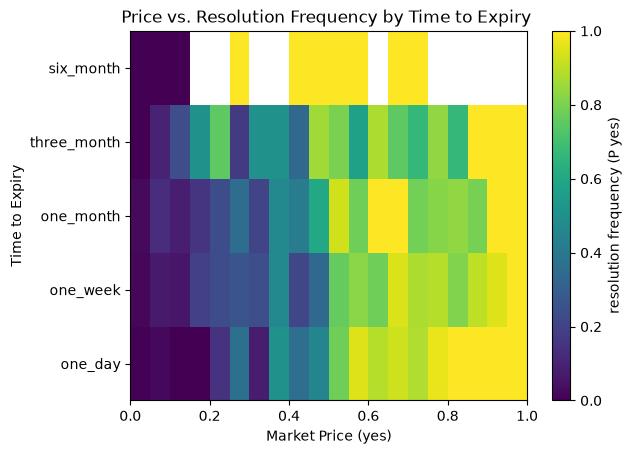

In [5]:
# we are now going to create a heat map visualiser for our results
# y will be our options for time expiry
# x will be 0 to 1 pm 5%
# z will be the resolution percentage

# the time-frame options, in the same order as split_df_one_condition in Reports_HT
time_frames = ["one_day", "one_week", "one_month", "three_month", "six_month"]
y = np.arange(1, 7, 1)       # 6 edges -> 5 squares, step of 1
x = np.arange(0, 1.05, 0.05) # 21 edges -> 20 squares, 0 to 1 in steps of 0.05
z = np.full((len(y) - 1, len(x) - 1), np.nan)  # 2D float array, nan = no data

report = Report(market_data_df)
for i, t in enumerate(time_frames):
    for j in range(len(x) - 1):
        center = x[j] + 0.025          # centre of the price bin
        try:
            z[i, j] = report.freq_report(t, center, 0.025)[2]
        except ZeroDivisionError:
            pass                        # no markets in this bin -> leave as nan

fig, ax = plt.subplots()
mesh = ax.pcolormesh(x, y, z, vmin=0, vmax=1)  # fix scale to 0-1 probabilities

# colour legend showing which colour maps to which resolution probability
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("resolution frequency (P yes)")

# label each y square (centre of the square) with its time-frame option
ax.set_yticks(y[:-1] + 0.5)
ax.set_yticklabels(time_frames)
ax.set_title("Price vs. Resolution Frequency by Time to Expiry ")
ax.set_xlabel("Market Price (yes)")
ax.set_ylabel("Time to Expiry")

plt.show()


In [6]:
#results of the above as a table
rpt = Report(market_data_df)
rpt.report_table("count", 0.1)

,Price,six_month,three_month,one_month,one_week,one_day
0,0.0,4,52,127,219,412
1,0.1,3,40,80,93,74
2,0.2,0,20,26,53,36
3,0.3,2,11,31,40,22
4,0.4,1,7,28,55,31
5,0.5,4,12,27,67,28
6,0.6,1,15,34,53,28
7,0.7,2,7,28,40,27
8,0.8,0,9,23,47,52
9,0.9,0,8,32,57,70
